# Norwegian Gas Outages and TTF: Event-Study Analysis

This notebook examines the distribution of near-term TTF price movements around eligible Norwegian gas outage announcements.

Event definitions, market-date alignment and response windows were specified in the preceding validation and alignment notebooks before the resulting return distributions were examined.

The analysis begins with the 130 unique TTF market anchors rather than the 166 individual announcements. This prevents multiple Gassco messages mapped to the same market window from repeatedly counting the same TTF price movement.

A separate sample of 82 non-overlapping anchors is used for formal inference to reduce dependence created by overlapping market windows, while the full 130-anchor sample is retained for descriptive analysis.

The analysis is descriptive before it is inferential. Return distributions, signs, dispersion, outliers and sensitivity across event windows are examined before formal statistical tests are considered.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ANCHOR_PATH = (
    PROCESSED_DIR
    / "gassco_ttf_event_windows_unique_anchors.csv"
)

NONOVERLAP_PATH = (
    PROCESSED_DIR
    / "gassco_ttf_event_windows_nonoverlap.csv"
)

anchors = pd.read_csv(
    ANCHOR_PATH,
    parse_dates=[
        "date_m1",
        "date_0",
        "date_p1",
        "date_p2"
    ]
)

nonoverlap = pd.read_csv(
    NONOVERLAP_PATH,
    parse_dates=[
        "date_m1",
        "date_0",
        "date_p1",
        "date_p2"
    ]
)

print("Unique-anchor sample:", anchors.shape)
print("Non-overlapping sample:", nonoverlap.shape)

print(
    "\nAnchor date range:",
    anchors["date_0"].min(),
    "to",
    anchors["date_0"].max()
)

print("\nMissing event returns:")
print(
    anchors[
        [
            "return_m1_0",
            "return_0_p1",
            "return_m1_p1",
            "return_0_p2"
        ]
    ].isna().sum()
)

Unique-anchor sample: (130, 13)
Non-overlapping sample: (82, 14)

Anchor date range: 2024-09-03 00:00:00 to 2026-08-31 00:00:00

Missing event returns:
return_m1_0     0
return_0_p1     0
return_m1_p1    0
return_0_p2     0
dtype: int64


## Event-return distributions

The first stage of the event study describes the distribution of TTF returns around the 130 unique market anchors.

Four event windows are examined:

- \(r_{-1,0}\): previous observed TTF price to the anchor-date price.
- \(r_{0,+1}\): anchor-date price to the next observed TTF price.
- \(r_{-1,+1}\): previous observed TTF price to the next observed TTF price.
- \(r_{0,+2}\): anchor-date price to the second subsequent observed TTF price.

Mean returns alone may be sensitive to a small number of large market moves. The analysis therefore reports the median, dispersion, quantiles and proportion of positive observations alongside the mean.

In [2]:
# Descriptive statistics for event-window returns

return_labels = {
    "return_m1_0": "r[-1,0]",
    "return_0_p1": "r[0,+1]",
    "return_m1_p1": "r[-1,+1]",
    "return_0_p2": "r[0,+2]"
}

summary_rows = []

for column, label in return_labels.items():
    x = anchors[column].dropna()

    summary_rows.append({
        "window": label,
        "n": len(x),
        "mean_pct": 100 * x.mean(),
        "median_pct": 100 * x.median(),
        "std_pct": 100 * x.std(ddof=1),
        "p10_pct": 100 * x.quantile(0.10),
        "p25_pct": 100 * x.quantile(0.25),
        "p75_pct": 100 * x.quantile(0.75),
        "p90_pct": 100 * x.quantile(0.90),
        "min_pct": 100 * x.min(),
        "max_pct": 100 * x.max(),
        "positive_share_pct": 100 * (x > 0).mean()
    })

return_summary = pd.DataFrame(summary_rows)

display(
    return_summary.round(3)
)

,window,n,mean_pct,median_pct,std_pct,p10_pct,p25_pct,p75_pct,p90_pct,min_pct,max_pct,positive_share_pct
0,"r[-1,0]",130,0.032,-0.167,3.231,-4.108,-2.025,2.068,4.657,-7.343,8.851,49.231
1,"r[0,+1]",130,-0.074,0.279,3.268,-3.576,-1.750,2.112,3.654,-17.493,7.210,51.538
2,"r[-1,+1]",130,-0.042,0.226,4.403,-5.182,-2.280,2.942,5.349,-13.080,10.687,52.308
3,"r[0,+2]",130,0.048,0.200,4.241,-4.906,-2.035,2.931,4.615,-13.907,10.231,52.308


### Initial event-return findings

Across the 130 unique TTF market anchors, the unconditional return distributions show little evidence of a common directional price response.

Mean log returns are close to zero across all four predefined windows, ranging from -0.074% to +0.048%. Median returns are similarly small, while the proportion of positive observations ranges from approximately 49% to 52%. The typical event date therefore does not exhibit a clear uniformly positive or negative TTF movement.

This does not imply that Norwegian outage information is irrelevant to the market. Return dispersion around the event dates is substantial. For the wider \([-1,+1]\) window, for example, the standard deviation is approximately 4.40%, with observed returns ranging from -13.08% to +10.69%.

The results therefore suggest considerable heterogeneity rather than a single unconditional response. Large positive and negative market movements coexist within the sample, making the mean response potentially sensitive to tail observations and to differences between outage events.

The next stage examines the shape and tails of these distributions before formal inference or relationships with outage characteristics are considered.

In [3]:
# Inspect largest positive and negative event-window observations

TAIL_N = 10

for column, label in return_labels.items():

    print("\n" + "=" * 65)
    print(label)
    print("=" * 65)

    largest_negative = (
        anchors[
            [
                "date_0",
                column
            ]
        ]
        .nsmallest(TAIL_N, column)
        .copy()
    )

    largest_positive = (
        anchors[
            [
                "date_0",
                column
            ]
        ]
        .nlargest(TAIL_N, column)
        .copy()
    )

    largest_negative["return_pct"] = (
        100 * largest_negative[column]
    )

    largest_positive["return_pct"] = (
        100 * largest_positive[column]
    )

    print("\nLargest negative observations:")
    display(
        largest_negative[
            ["date_0", "return_pct"]
        ].reset_index(drop=True)
    )

    print("\nLargest positive observations:")
    display(
        largest_positive[
            ["date_0", "return_pct"]
        ].reset_index(drop=True)
    )


r[-1,0]

Largest negative observations:


,date_0,return_pct
0,2025-04-09,-7.342668
1,2026-05-06,-6.661202
2,2024-09-19,-6.330412
3,2026-04-13,-6.287678
4,2026-06-14,-5.319340
5,2025-04-03,-5.121294
6,2026-02-16,-5.038682
7,2026-04-15,-4.639594
8,2024-09-16,-4.495300
9,2024-12-12,-4.320771



Largest positive observations:


,date_0,return_pct
0,2026-01-21,8.850569
1,2026-04-19,7.992961
2,2026-04-29,7.209551
3,2025-01-13,6.978353
4,2026-08-06,6.223524
5,2026-03-09,5.587863
6,2024-09-25,5.242360
7,2025-10-06,5.199920
8,2026-07-08,5.118379
9,2026-03-06,5.099264



r[0,+1]

Largest negative observations:


...

,date_0,return_pct
0,2026-03-06,10.687127
1,2026-07-17,9.757267
2,2026-07-08,7.297554
3,2026-06-19,6.789824
4,2024-09-25,6.760824
5,2026-07-21,6.260341
6,2026-04-22,5.937389
7,2026-01-21,5.928784
8,2026-08-06,5.819258
9,2025-10-06,5.591711



r[0,+2]

Largest negative observations:


,date_0,return_pct
0,2025-06-20,-13.907196
1,2026-03-09,-12.160545
2,2026-03-06,-11.905527
3,2025-02-11,-11.709299
4,2026-04-13,-11.432287
5,2025-02-12,-9.364971
6,2026-06-10,-6.649687
7,2026-04-15,-6.563577
8,2024-12-10,-6.222297
9,2024-12-12,-6.085097



Largest positive observations:


,date_0,return_pct
0,2026-01-19,10.231024
1,2024-09-19,9.034338
2,2026-01-08,8.796763
3,2026-04-20,7.780269
4,2026-07-12,7.058026
5,2024-09-24,6.760824
6,2025-01-27,6.655792
7,2025-06-17,5.731952
8,2026-04-28,5.343922
9,2026-08-31,5.334393


### Tail behaviour

The event-return distributions contain substantial positive and negative tail observations. This reinforces the distinction between a near-zero average response and an absence of economically meaningful price movements.

Several event dates also appear in the tails of multiple response windows. For example, the 9 March 2026 anchor combines a positive \([-1,0]\) return of approximately 5.59% with a subsequent \([0,+1]\) return of approximately -17.49%, producing a wider \([-1,+1]\) return of approximately -11.91%. By contrast, the 6 March 2026 anchor records positive returns across both adjacent intervals and a \([-1,+1]\) return of approximately 10.69%.

Such reversals and repeated extreme dates indicate that event-window returns may contain substantial market-wide variation in addition to information associated with individual Norwegian outage announcements.

Extreme observations are therefore retained rather than removed mechanically. Their influence will be examined through robust descriptive statistics, the non-overlapping event specification and subsequent investigation of relevant event and market conditions.

In [4]:
# QA weekend-dated event anchors

weekend_check = anchors.copy()

weekend_check["anchor_weekday"] = (
    weekend_check["date_0"].dt.day_name()
)

weekend_anchors = weekend_check.loc[
    weekend_check["anchor_weekday"].isin(
        ["Saturday", "Sunday"]
    ),
    [
        "date_m1",
        "date_0",
        "anchor_weekday",
        "date_p1",
        "price_m1",
        "price_0",
        "price_p1"
    ]
].sort_values("date_0")

print(
    "Event anchors dated Saturday or Sunday:",
    len(weekend_anchors)
)

display(
    weekend_anchors.reset_index(drop=True)
)

Event anchors dated Saturday or Sunday: 8


,date_m1,date_0,anchor_weekday,date_p1,price_m1,price_0,price_p1
0,2026-04-17,2026-04-19,Sunday,2026-04-20,38.769,41.995,40.292
1,2026-05-01,2026-05-03,Sunday,2026-05-04,45.766,45.330,48.143
2,2026-05-08,2026-05-10,Sunday,2026-05-11,44.143,45.000,46.233
3,2026-05-15,2026-05-17,Sunday,2026-05-18,50.167,51.135,50.250
4,2026-06-12,2026-06-14,Sunday,2026-06-15,46.773,44.350,42.507
5,2026-06-19,2026-06-21,Sunday,2026-06-22,42.092,43.370,41.887
6,2026-07-10,2026-07-12,Sunday,2026-07-13,48.655,49.350,51.275
7,2026-08-14,2026-08-16,Sunday,2026-08-17,61.424,62.355,61.757


### Weekend-date validation

Eight of the 130 event anchors occur on a Sunday. These observations were investigated because a conventional Monday-to-Friday calendar would otherwise classify them as non-trading dates.

The official ICE specification for Dutch TTF Natural Gas Futures confirms that the market opens on Sunday, while Saturday is closed. Sunday-dated observations in the historical TTF series are therefore not treated as calendar errors.

This finding also supports the decision to construct event windows from the observed TTF date sequence rather than imposing a generic weekday trading calendar.

The market-price dataset is a continuous futures series obtained from Investing.com. Investing.com describes the historical `Price` field as the closing price. It should therefore be interpreted as the vendor-reported closing price for the continuous series rather than as an official ICE settlement price.

## Robustness to overlapping event windows

The full market-event sample contains 130 unique TTF anchor dates. However, some event windows overlap in trading time and therefore share underlying close-to-close returns.

A robustness sample of 82 anchors was constructed previously by requiring retained anchors to be separated by at least three observed TTF trading intervals. This prevents the retained \([-1,+1]\) windows from sharing return intervals.

The descriptive return distributions are compared across the full and non-overlapping samples. The purpose is not to treat the reduced sample as inherently superior, but to assess whether the main findings depend materially on overlapping market observations.

In [5]:
# Compare full unique-anchor sample with non-overlapping robustness sample

comparison_rows = []

samples = {
    "Full unique anchors": anchors,
    "Non-overlapping anchors": nonoverlap
}

for sample_name, sample_df in samples.items():

    for column, label in return_labels.items():

        x = sample_df[column].dropna()

        comparison_rows.append({
            "sample": sample_name,
            "window": label,
            "n": len(x),
            "mean_pct": 100 * x.mean(),
            "median_pct": 100 * x.median(),
            "std_pct": 100 * x.std(ddof=1),
            "positive_share_pct": 100 * (x > 0).mean(),
            "p10_pct": 100 * x.quantile(0.10),
            "p90_pct": 100 * x.quantile(0.90)
        })

sample_comparison = pd.DataFrame(comparison_rows)

display(
    sample_comparison.round(3)
)

,sample,window,n,mean_pct,median_pct,std_pct,positive_share_pct,p10_pct,p90_pct
0,Full unique anchors,"r[-1,0]",130,0.032,-0.167,3.231,49.231,-4.108,4.657
1,Full unique anchors,"r[0,+1]",130,-0.074,0.279,3.268,51.538,-3.576,3.654
2,Full unique anchors,"r[-1,+1]",130,-0.042,0.226,4.403,52.308,-5.182,5.349
3,Full unique anchors,"r[0,+2]",130,0.048,0.200,4.241,52.308,-4.906,4.615
4,Non-overlapping anchors,"r[-1,0]",82,-0.324,-0.547,3.276,43.902,-4.300,3.783
5,Non-overlapping anchors,"r[0,+1]",82,0.098,0.057,3.107,50.000,-3.697,4.011
6,Non-overlapping anchors,"r[-1,+1]",82,-0.226,-0.050,4.715,50.000,-7.235,5.402
7,Non-overlapping anchors,"r[0,+2]",82,0.064,0.163,4.458,51.220,-4.747,4.933


### Overlap-robustness findings

Removing overlapping event windows does not materially change the central descriptive finding.

Across the 82 non-overlapping anchors, mean returns remain small relative to the dispersion of TTF price movements. Depending on the response window, mean returns range from approximately -0.32% to +0.10%, while standard deviations range from approximately 3.11% to 4.72%. The proportion of positive observations remains close to one half for most windows.

Some distributional characteristics do change. The \([-1,0]\) window becomes more negative in the non-overlapping sample, with its mean moving from +0.03% to -0.32% and its positive share falling from 49.2% to 43.9%. The lower tail of the wider \([-1,+1]\) window also becomes more negative.

These differences show that event clustering affects some features of the observed distribution. However, removing overlapping windows does not uncover a consistent positive or negative response across the event windows.

The non-overlapping specification therefore supports the broader descriptive result: Norwegian outage announcements occur alongside substantial TTF price variation, but the unconditional event sample does not exhibit a common directional price response.

## Benchmarking event-window returns

The preceding analysis describes TTF returns around Norwegian outage announcements, but a raw event-window return is not necessarily an abnormal market response.

TTF prices can move substantially in the absence of a Norwegian outage announcement. The event distributions are therefore compared with returns calculated over equivalent horizons elsewhere in the same TTF price series.

The benchmark is constructed from the validated TTF observations using the same return definitions as the event study. Dates whose return windows overlap with an identified Gassco event window are excluded from the benchmark to reduce contamination between event and non-event observations.

This comparison asks whether the distribution of TTF movements around outage announcements differs from the distribution of comparable TTF movements observed outside those event windows. It does not by itself establish that any difference is caused by the outage announcement.

In [6]:
# Load validated TTF source for benchmark construction

TTF_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ttf"
    / "ice_dutch_ttf_futures_2024-07-01_to_2026-09-17.csv"
)

ttf = pd.read_csv(TTF_PATH)

ttf["trading_date"] = pd.to_datetime(
    ttf["Date"],
    format="%d/%m/%Y",
    errors="raise"
)

ttf["price"] = pd.to_numeric(
    ttf["Price"],
    errors="raise"
)

ttf = (
    ttf[["trading_date", "price"]]
    .sort_values("trading_date")
    .reset_index(drop=True)
)

ttf["ttf_index"] = np.arange(len(ttf))

print("TTF observations:", len(ttf))
print("Date range:", ttf["trading_date"].min(), "to", ttf["trading_date"].max())
print("Duplicate dates:", ttf["trading_date"].duplicated().sum())

display(ttf.head())

TTF observations: 591
Date range: 2024-07-01 00:00:00 to 2026-09-17 00:00:00
Duplicate dates: 0


,trading_date,price,ttf_index
0,2024-07-01,33.485,0
1,2024-07-02,33.685,1
2,2024-07-03,32.691,2
3,2024-07-04,33.246,3
4,2024-07-05,33.067,4


In [7]:
# Construct equivalent return windows for every possible TTF anchor

ttf["price_m1"] = ttf["price"].shift(1)
ttf["price_p1"] = ttf["price"].shift(-1)
ttf["price_p2"] = ttf["price"].shift(-2)

ttf["return_m1_0"] = np.log(
    ttf["price"] / ttf["price_m1"]
)

ttf["return_0_p1"] = np.log(
    ttf["price_p1"] / ttf["price"]
)

ttf["return_m1_p1"] = np.log(
    ttf["price_p1"] / ttf["price_m1"]
)

ttf["return_0_p2"] = np.log(
    ttf["price_p2"] / ttf["price"]
)

benchmark_candidates = ttf.dropna(
    subset=list(return_labels.keys())
).copy()

print(
    "Candidate benchmark anchors before event exclusion:",
    len(benchmark_candidates)
)

Candidate benchmark anchors before event exclusion: 588


In [8]:
# Identify all TTF dates touched by an event window

event_dates = set()

for column in ["date_m1", "date_0", "date_p1", "date_p2"]:
    event_dates.update(
        anchors[column].dropna()
    )

print("Unique TTF dates touched by event windows:", len(event_dates))

Unique TTF dates touched by event windows: 338


In [9]:
# Attach surrounding dates to each candidate benchmark anchor

benchmark_candidates["date_m1"] = (
    benchmark_candidates["trading_date"].shift(1)
)

benchmark_candidates["date_p1"] = (
    benchmark_candidates["trading_date"].shift(-1)
)

benchmark_candidates["date_p2"] = (
    benchmark_candidates["trading_date"].shift(-2)
)

benchmark_candidates = benchmark_candidates.dropna(
    subset=["date_m1", "date_p1", "date_p2"]
).copy()

benchmark_candidates["contaminated"] = (
    benchmark_candidates["date_m1"].isin(event_dates)
    | benchmark_candidates["trading_date"].isin(event_dates)
    | benchmark_candidates["date_p1"].isin(event_dates)
    | benchmark_candidates["date_p2"].isin(event_dates)
)

benchmark = benchmark_candidates.loc[
    ~benchmark_candidates["contaminated"]
].copy()

print("Candidate anchors:", len(benchmark_candidates))
print(
    "Excluded because of event-window contamination:",
    benchmark_candidates["contaminated"].sum()
)
print("Clean benchmark anchors:", len(benchmark))

Candidate anchors: 585
Excluded because of event-window contamination: 423
Clean benchmark anchors: 162


### Benchmark contamination rule

Norwegian outage announcements occur frequently within the sample, meaning that a single universal exclusion rule would remove a large proportion of otherwise usable non-event observations.

Benchmark contamination is therefore defined separately for each response horizon. A candidate benchmark window is excluded only when one of the TTF observations required to calculate that specific return overlaps with a date contained in the corresponding event windows.

This preserves uncontaminated market observations without unnecessarily excluding dates that are irrelevant to the return horizon being analysed.

In [10]:
# Reconstruct candidate TTF return windows cleanly from the full series

ttf_benchmark = ttf.copy()

ttf_benchmark["date_m1"] = ttf_benchmark["trading_date"].shift(1)
ttf_benchmark["date_p1"] = ttf_benchmark["trading_date"].shift(-1)
ttf_benchmark["date_p2"] = ttf_benchmark["trading_date"].shift(-2)

ttf_benchmark["price_m1"] = ttf_benchmark["price"].shift(1)
ttf_benchmark["price_p1"] = ttf_benchmark["price"].shift(-1)
ttf_benchmark["price_p2"] = ttf_benchmark["price"].shift(-2)

ttf_benchmark["return_m1_0"] = np.log(
    ttf_benchmark["price"] / ttf_benchmark["price_m1"]
)

ttf_benchmark["return_0_p1"] = np.log(
    ttf_benchmark["price_p1"] / ttf_benchmark["price"]
)

ttf_benchmark["return_m1_p1"] = np.log(
    ttf_benchmark["price_p1"] / ttf_benchmark["price_m1"]
)

ttf_benchmark["return_0_p2"] = np.log(
    ttf_benchmark["price_p2"] / ttf_benchmark["price"]
)


# Dates used by the actual event windows, defined separately
# for each return horizon.

event_date_sets = {
    "return_m1_0": set(
        anchors["date_m1"].dropna()
    ) | set(
        anchors["date_0"].dropna()
    ),

    "return_0_p1": set(
        anchors["date_0"].dropna()
    ) | set(
        anchors["date_p1"].dropna()
    ),

    "return_m1_p1": set(
        anchors["date_m1"].dropna()
    ) | set(
        anchors["date_0"].dropna()
    ) | set(
        anchors["date_p1"].dropna()
    ),

    "return_0_p2": set(
        anchors["date_0"].dropna()
    ) | set(
        anchors["date_p1"].dropna()
    ) | set(
        anchors["date_p2"].dropna()
    )
}


# Required dates for each hypothetical benchmark return.

required_date_columns = {
    "return_m1_0": [
        "date_m1",
        "trading_date"
    ],

    "return_0_p1": [
        "trading_date",
        "date_p1"
    ],

    "return_m1_p1": [
        "date_m1",
        "trading_date",
        "date_p1"
    ],

    "return_0_p2": [
        "trading_date",
        "date_p1",
        "date_p2"
    ]
}


benchmark_samples = {}

summary_rows = []

for return_col, required_cols in required_date_columns.items():

    candidate = ttf_benchmark.dropna(
        subset=[return_col] + required_cols
    ).copy()

    contaminated = pd.Series(
        False,
        index=candidate.index
    )

    event_dates_for_window = event_date_sets[return_col]

    for date_col in required_cols:
        contaminated |= candidate[date_col].isin(
            event_dates_for_window
        )

    clean = candidate.loc[~contaminated].copy()

    benchmark_samples[return_col] = clean

    summary_rows.append({
        "window": return_labels[return_col],
        "candidate_anchors": len(candidate),
        "excluded_contaminated": int(contaminated.sum()),
        "clean_benchmark_anchors": len(clean)
    })


benchmark_sample_sizes = pd.DataFrame(summary_rows)

display(benchmark_sample_sizes)

,window,candidate_anchors,excluded_contaminated,clean_benchmark_anchors
0,"r[-1,0]",590,289,301
1,"r[0,+1]",590,289,301
2,"r[-1,+1]",589,375,214
3,"r[0,+2]",589,375,214


### Benchmark sample construction

Applying the contamination rule separately by response horizon produces 301 clean benchmark observations for each one-interval return and 214 for each two-interval return.

The wider windows lose more candidate observations because each return spans three TTF observations rather than two, increasing the probability that the hypothetical benchmark window intersects an identified Gassco event window.

The benchmark therefore remains substantially larger than the event sample while avoiding unnecessary exclusion of observations outside the relevant return horizon.

In [11]:
# Compare event-window and uncontaminated benchmark distributions

event_benchmark_rows = []

for return_col, label in return_labels.items():

    event_x = anchors[return_col].dropna()
    benchmark_x = benchmark_samples[return_col][return_col].dropna()

    for sample_name, x in [
        ("Event anchors", event_x),
        ("Non-event benchmark", benchmark_x)
    ]:

        event_benchmark_rows.append({
            "window": label,
            "sample": sample_name,
            "n": len(x),
            "mean_pct": 100 * x.mean(),
            "median_pct": 100 * x.median(),
            "std_pct": 100 * x.std(ddof=1),
            "mean_abs_return_pct": 100 * x.abs().mean(),
            "median_abs_return_pct": 100 * x.abs().median(),
            "positive_share_pct": 100 * (x > 0).mean(),
            "p10_pct": 100 * x.quantile(0.10),
            "p90_pct": 100 * x.quantile(0.90)
        })

event_benchmark_comparison = pd.DataFrame(
    event_benchmark_rows
)

display(
    event_benchmark_comparison.round(3)
)

,window,sample,n,mean_pct,median_pct,std_pct,mean_abs_return_pct,median_abs_return_pct,positive_share_pct,p10_pct,p90_pct
0,"r[-1,0]",Event anchors,130,0.032,-0.167,3.231,2.601,2.066,49.231,-4.108,4.657
1,"r[-1,0]",Non-event benchmark,301,0.218,0.199,3.994,2.634,1.932,53.156,-3.249,4.141
2,"r[0,+1]",Event anchors,130,-0.074,0.279,3.268,2.398,1.934,51.538,-3.576,3.654
3,"r[0,+1]",Non-event benchmark,301,0.290,0.248,4.058,2.719,2.086,53.488,-3.280,4.096
4,"r[-1,+1]",Event anchors,130,-0.042,0.226,4.403,3.339,2.596,52.308,-5.182,5.349
5,"r[-1,+1]",Non-event benchmark,214,0.295,-0.037,6.322,3.739,2.453,49.533,-4.706,5.265
6,"r[0,+2]",Event anchors,130,0.048,0.200,4.241,3.167,2.419,52.308,-4.906,4.615
7,"r[0,+2]",Non-event benchmark,214,0.413,0.133,6.298,3.710,2.290,51.402,-4.639,5.562


### Event versus non-event benchmark

The benchmark comparison does not indicate that Norwegian outage-announcement dates are associated with systematically larger TTF movements than uncontaminated non-event dates.

Mean event returns remain close to zero across the four response windows and are slightly below the corresponding benchmark means. Positive-return frequencies remain close to one half in both samples, providing no clear descriptive evidence of a common directional response.

The magnitude results are also important. Mean absolute returns around event anchors are similar to or lower than those observed in the non-event benchmark. For example, the mean absolute \([0,+1]\) return is approximately 2.40% for event anchors compared with 2.72% for the benchmark. For the wider \([0,+2]\) window, the corresponding values are approximately 3.17% and 3.71%.

Standard deviations are likewise lower in the event sample across all four specifications. This difference is particularly large for the two-interval windows, although the comparison between mean and median absolute returns indicates that extreme benchmark observations may contribute substantially to this difference in dispersion.

These descriptive results therefore provide little evidence that the unconditional set of Norwegian outage announcements is associated with either a common direction or systematically larger TTF price movements. This does not imply that individual outages are unimportant: effects may depend on outage size, timing, market expectations or prevailing gas-market conditions.

In [12]:
# Compare calendar composition of event and benchmark samples

calendar_rows = []

for return_col, label in return_labels.items():

    event_dates = anchors["date_0"].dropna()

    benchmark_dates = (
        benchmark_samples[return_col]["trading_date"]
        .dropna()
    )

    for sample_name, dates in [
        ("Event anchors", event_dates),
        ("Non-event benchmark", benchmark_dates)
    ]:

        dates = pd.to_datetime(dates)

        counts = (
            dates.dt.to_period("M")
            .value_counts()
            .sort_index()
        )

        for month, n in counts.items():
            calendar_rows.append({
                "window": label,
                "sample": sample_name,
                "month": str(month),
                "n": n
            })

calendar_composition = pd.DataFrame(calendar_rows)

calendar_pivot = (
    calendar_composition
    .pivot_table(
        index="month",
        columns=["window", "sample"],
        values="n",
        fill_value=0
    )
)

display(calendar_pivot)

window       r[-1,+1]                           r[-1,0]                      \
sample  Event anchors Non-event benchmark Event anchors Non-event benchmark   
month                                                                         
2024-07           0.0                22.0           0.0                22.0   
2024-08           0.0                21.0           0.0                22.0   
2024-09          10.0                 0.0          10.0                 2.0   
2024-10           7.0                 0.0           7.0                 6.0   
2024-11           5.0                 9.0           5.0                12.0   
2024-12           7.0                 3.0           7.0                 6.0   
2025-01           4.0                 4.0           4.0                10.0   
2025-02           5.0                10.0           5.0                12.0   
2025-03           4.0                11.0           4.0                13.0   
2025-04           6.0                 0.0           6.0                 4.0   
2025-05           8.0                 4.0           8.0                 7.0   
2025-06           5.0                 4.0           5.0                 9.0   
2025-07           4.0                 6.0           4.0                11.0   
2025-08           4.0                 6.0           4.0                10.0   
2025-09           2.0                14.0           2.0                17.0   
2025-10           7.0                 0.0           7.0                 5.0   
2025-11           4.0                 8.0           4.0                11.0   
2025-12           0.0                21.0           0.0                21.0   
2026-01           3.0                 9.0           3.0                13.0   
2026-02           2.0                10.0           2.0                14.0   
2026-03           3.0                12.0           3.0                15.0   
2026-04           8.0                 5.0           8.0                 6.0   
2026-05           8.0                 3.0           8.0                 7.0   
2026-06           9.0                 6.0           9.0                 9.0   
2026-07           6.0                10.0           6.0                14.0   
2026-08           9.0                 4.0           9.0                 9.0   
2026-09           0.0                12.0           0.0                14.0   

window        r[0,+1]                           r[0,+2]                      
sample  Event anchors Non-event benchmark Event anchors Non-event benchmark  
month                                                                        
2024-07           0.0                23.0           0.0                23.0  
2024-08           0.0                22.0           0.0                21.0  
2024-09          10.0                 2.0          10.0                 0.0  
2024-10           7.0                 6.0           7.0                 0.0  
2024-11           5.0                12.0           5.0                 9.0  
2024-12           7.0                 6.0           7.0                 3.0  
2025-01           4.0                10.0           4.0                 4.0  
2025-02           5.0                12.0           5.0                10.0  
2025-03           4.0                13.0           4.0                11.0  
2025-04           6.0                 4.0           6.0                 0.0  
2025-05           8.0                 7.0           8.0                 4.0  
2025-06           5.0                 9.0           5.0                 4.0  
2025-07           4.0                11.0           4.0                 6.0  
2025-08           4.0                10.0           4.0                 6.0  
2025-09           2.0                17.0           2.0                14.0  
2025-10           7.0                 5.0           7.0                 0.0  
2025-11           4.0                11.0           4.0                 8.0  
2025-12           0.0                21.0           0.0              

### Calendar composition of the benchmark

The uncontaminated benchmark is not distributed uniformly across the event-study period.

Some months containing numerous outage-event anchors provide few or no uncontaminated benchmark observations, while other periods contain many benchmark observations but few or no events. The benchmark also includes observations before the first event anchor and after the final event anchor.

Consequently, a pooled comparison between all event and non-event observations may confound event status with changes in the underlying TTF market regime. Differences in return dispersion cannot therefore be interpreted as an outage-announcement effect from the unconditional benchmark alone.

The pooled benchmark is retained as a descriptive reference, but a more local comparison is required before formal event-versus-non-event inference.

In [13]:
# Diagnostic: distance from each event anchor to nearby clean controls
# for the post-anchor r[0,+1] response.

# ---------------------------------------------------------
# 1. Map each event anchor back to its sequential TTF index
# ---------------------------------------------------------

date_to_index = (
    ttf_benchmark
    .set_index("trading_date")["ttf_index"]
)

anchors_with_index = anchors.copy()

anchors_with_index["ttf_index"] = (
    anchors_with_index["date_0"]
    .map(date_to_index)
)

print(
    "Event anchors missing a TTF index:",
    anchors_with_index["ttf_index"].isna().sum()
)

# ---------------------------------------------------------
# 2. Build clean r[0,+1] control pool
# ---------------------------------------------------------

control_pool = (
    benchmark_samples["return_0_p1"]
    [["trading_date", "ttf_index", "return_0_p1"]]
    .copy()
)

print(
    "Clean r[0,+1] control observations:",
    len(control_pool)
)

# ---------------------------------------------------------
# 3. Find five nearest clean controls for each event
# ---------------------------------------------------------

event_control_diagnostics = []

for _, event in anchors_with_index.iterrows():

    event_date = event["date_0"]
    event_idx = event["ttf_index"]

    candidates = control_pool.copy()

    candidates["index_distance"] = (
        candidates["ttf_index"] - event_idx
    ).abs()

    candidates["calendar_distance_days"] = (
        candidates["trading_date"] - event_date
    ).abs().dt.days

    nearest = (
        candidates
        .sort_values(
            ["index_distance", "calendar_distance_days"]
        )
        .head(5)
    )

    row = {
        "event_date": event_date
    }

    for rank, (_, control) in enumerate(
        nearest.iterrows(),
        start=1
    ):
        row[f"control_{rank}_date"] = (
            control["trading_date"]
        )

        row[f"control_{rank}_index_distance"] = (
            control["index_distance"]
        )

        row[f"control_{rank}_calendar_days"] = (
            control["calendar_distance_days"]
        )

    event_control_diagnostics.append(row)

control_diagnostics = pd.DataFrame(
    event_control_diagnostics
)

# ---------------------------------------------------------
# 4. Display examples
# ---------------------------------------------------------

display_columns = ["event_date"]

for rank in range(1, 6):
    display_columns.extend([
        f"control_{rank}_date",
        f"control_{rank}_index_distance"
    ])

display(
    control_diagnostics[
        display_columns
    ].head(15)
)

# ---------------------------------------------------------
# 5. Summarise control distances
# ---------------------------------------------------------

distance_cols = [
    f"control_{rank}_index_distance"
    for rank in range(1, 6)
]

print("\nNearest clean-control distance summary:")

display(
    control_diagnostics[
        distance_cols
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .round(2)
)

Event anchors missing a TTF index: 0
Clean r[0,+1] control observations: 301


,event_date,control_1_date,control_1_index_distance,control_2_date,control_2_index_distance,control_3_date,control_3_index_distance,control_4_date,control_4_index_distance,control_5_date,control_5_index_distance
0,2024-09-03,2024-08-30,2,2024-08-29,3,2024-08-28,4,2024-08-27,5,2024-08-26,6
1,2024-09-04,2024-08-30,3,2024-08-29,4,2024-08-28,5,2024-09-11,5,2024-08-27,6
2,2024-09-09,2024-09-11,2,2024-09-12,3,2024-08-30,6,2024-08-29,7,2024-08-28,8
3,2024-09-16,2024-09-12,2,2024-09-11,3,2024-08-30,11,2024-10-02,12,2024-08-29,12
4,2024-09-19,2024-09-12,5,2024-09-11,6,2024-10-02,9,2024-10-03,10,2024-08-30,14
5,2024-09-23,2024-10-02,7,2024-09-12,7,2024-10-03,8,2024-09-11,8,2024-10-09,12
6,2024-09-24,2024-10-02,6,2024-10-03,7,2024-09-12,8,2024-09-11,9,2024-10-09,11
7,2024-09-25,2024-10-02,5,2024-10-03,6,2024-09-12,9,2024-09-11,10,2024-10-09,10
8,2024-09-26,2024-10-02,4,2024-10-03,5,2024-10-09,9,2024-09-12,10,2024-10-10,10
9,2024-09-30,2024-10-02,2,2024-10-03,3,2024-10-09,7,2024-10-10,8,2024-09-12,12



Nearest clean-control distance summary:


,control_1_index_distance,control_2_index_distance,control_3_index_distance,control_4_index_distance,control_5_index_distance
count,130.00,130.00,130.00,130.00,130.00
mean,3.05,4.05,5.44,6.81,7.95
std,1.98,2.11,2.31,2.95,3.13
min,2.00,2.00,3.00,3.00,4.00
25%,2.00,3.00,4.00,5.00,6.00
50%,2.00,3.00,5.00,6.00,7.00
75%,3.00,5.00,7.00,8.00,10.00
90%,5.00,6.10,9.00,10.00,12.00
95%,7.00,7.55,10.00,13.00,14.00
max,12.00,13.00,14.00,19.00,19.00


### Feasibility of local controls

Clean non-event observations remain reasonably close to the event anchors despite the frequency and clustering of Gassco announcements.

For the post-anchor \([0,+1]\) return, the nearest uncontaminated control is a median of two observed TTF intervals from the corresponding event anchor. Approximately 75% of events have a clean control within three intervals, 90% within five intervals and 95% within seven intervals.

This supports the use of nearby non-event observations as a more comparable benchmark than the pooled non-event sample. Local controls reduce differences in calendar period and market regime, although they cannot eliminate confounding from other contemporaneous gas-market information.

In [14]:
# Construct symmetric local controls for the primary r[0,+1] window

control_pool = (
    benchmark_samples["return_0_p1"]
    [["trading_date", "ttf_index", "return_0_p1"]]
    .copy()
)

matched_rows = []

for _, event in anchors_with_index.iterrows():

    event_date = event["date_0"]
    event_idx = event["ttf_index"]
    event_return = event["return_0_p1"]

    # Clean controls before the event
    before = (
        control_pool.loc[
            control_pool["ttf_index"] < event_idx
        ]
        .assign(
            distance=lambda x:
                event_idx - x["ttf_index"]
        )
        .sort_values(
            ["distance", "trading_date"],
            ascending=[True, False]
        )
    )

    # Clean controls after the event
    after = (
        control_pool.loc[
            control_pool["ttf_index"] > event_idx
        ]
        .assign(
            distance=lambda x:
                x["ttf_index"] - event_idx
        )
        .sort_values(
            ["distance", "trading_date"],
            ascending=[True, True]
        )
    )

    before_control = (
        before.iloc[0] if len(before) > 0 else None
    )

    after_control = (
        after.iloc[0] if len(after) > 0 else None
    )

    matched_rows.append({
        "event_date": event_date,
        "event_index": event_idx,
        "event_return": event_return,

        "before_date":
            before_control["trading_date"]
            if before_control is not None else pd.NaT,

        "before_distance":
            before_control["distance"]
            if before_control is not None else np.nan,

        "before_return":
            before_control["return_0_p1"]
            if before_control is not None else np.nan,

        "after_date":
            after_control["trading_date"]
            if after_control is not None else pd.NaT,

        "after_distance":
            after_control["distance"]
            if after_control is not None else np.nan,

        "after_return":
            after_control["return_0_p1"]
            if after_control is not None else np.nan
    })

matched_controls = pd.DataFrame(matched_rows)

# Require controls on both sides
matched_controls = matched_controls.dropna(
    subset=[
        "before_return",
        "after_return"
    ]
).copy()

# Average of nearest clean pre- and post-event controls
matched_controls["local_control_return"] = (
    matched_controls[
        ["before_return", "after_return"]
    ].mean(axis=1)
)

# Event return relative to its local benchmark
matched_controls["event_minus_control"] = (
    matched_controls["event_return"]
    - matched_controls["local_control_return"]
)

print(
    "Events with symmetric local controls:",
    len(matched_controls),
    "of",
    len(anchors)
)

print("\nControl-distance summary:")

display(
    matched_controls[
        ["before_distance", "after_distance"]
    ]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
    .round(2)
)

print("\nEvent versus local-control return summary:")

summary = pd.DataFrame({
    "Event return": matched_controls["event_return"],
    "Local control": matched_controls["local_control_return"],
    "Event minus control":
        matched_controls["event_minus_control"]
}).agg(
    ["count", "mean", "median", "std"]
).T

summary[["mean", "median", "std"]] *= 100

display(summary.round(3))

Events with symmetric local controls: 130 of 130

Control-distance summary:


,before_distance,after_distance
count,130.00,130.00
mean,4.98,4.95
std,4.24,4.16
min,2.00,2.00
50%,3.00,4.00
75%,6.00,6.00
90%,9.10,8.10
95%,12.00,12.00
max,25.00,25.00



Event versus local-control return summary:


,count,mean,median,std
Event return,130.0,-0.074,0.279,3.268
Local control,130.0,1.272,0.850,2.573
Event minus control,130.0,-1.346,-1.026,3.950


### Preliminary local-control comparison

All 130 event anchors can be assigned clean observations on both sides of the event date. Median control distances are three observed TTF intervals before the event and four intervals after it, although some controls are substantially further away.

The preliminary matched comparison produces an average post-anchor event return of approximately -0.07%, compared with +1.27% for the local-control average. The resulting mean event-minus-control difference is approximately -1.35%.

This difference is not interpreted as an outage-announcement effect at this stage. Event clustering may cause individual control observations to be reused across multiple events, while the distance to an available clean control varies across events. The matching structure is therefore audited before statistical inference.

In [15]:
# Audit reuse of local control observations

before_usage = (
    matched_controls["before_date"]
    .value_counts()
    .rename("times_used_before")
)

after_usage = (
    matched_controls["after_date"]
    .value_counts()
    .rename("times_used_after")
)

control_usage = (
    pd.concat(
        [before_usage, after_usage],
        axis=1
    )
    .fillna(0)
)

control_usage["total_times_used"] = (
    control_usage["times_used_before"]
    + control_usage["times_used_after"]
)

control_usage = (
    control_usage
    .sort_values(
        "total_times_used",
        ascending=False
    )
)

print(
    "Total control assignments:",
    2 * len(matched_controls)
)

print(
    "Unique control dates used:",
    len(control_usage)
)

print(
    "Maximum number of uses for one control date:",
    int(control_usage["total_times_used"].max())
)

print(
    "Control dates used more than once:",
    int(
        (control_usage["total_times_used"] > 1)
        .sum()
    )
)

print("\nMost frequently reused controls:")

display(
    control_usage
    .head(15)
    .reset_index()
    .rename(columns={"index": "control_date"})
)

Total control assignments: 260
Unique control dates used: 86
Maximum number of uses for one control date: 12
Control dates used more than once: 59

Most frequently reused controls:


,control_date,times_used_before,times_used_after,total_times_used
0,2026-05-12,0.0,12.0,12.0
1,2026-04-10,12.0,0.0,12.0
2,2024-09-12,7.0,0.0,7.0
3,2024-10-02,0.0,7.0,7.0
4,2026-06-08,7.0,0.0,7.0
5,2026-06-23,0.0,7.0,7.0
6,2025-05-27,0.0,6.0,6.0
7,2025-05-09,6.0,0.0,6.0
8,2024-12-18,2.0,4.0,6.0
9,2025-10-15,4.0,1.0,5.0


In [16]:
# How concentrated are the 260 control assignments?

usage_distribution = (
    control_usage["total_times_used"]
    .value_counts()
    .sort_index()
    .rename_axis("times_used")
    .reset_index(name="number_of_control_dates")
)

display(usage_distribution)

top_10_share = (
    control_usage["total_times_used"]
    .head(10)
    .sum()
    / control_usage["total_times_used"].sum()
)

print(
    "Share of all control assignments represented by "
    f"the 10 most-used dates: {100 * top_10_share:.1f}%"
)

,times_used,number_of_control_dates
0,1.0,27
1,2.0,13
2,3.0,18
3,4.0,12
4,5.0,7
5,6.0,3
6,7.0,4
7,12.0,2


Share of all control assignments represented by the 10 most-used dates: 28.8%


### Control-reuse diagnostic

The nearest-neighbour matching design produces substantial reuse of individual control observations.

Across 260 pre- and post-event control assignments, only 86 unique TTF dates are used. Fifty-nine control dates are assigned to more than one event, individual dates are reused as many as 12 times, and the ten most frequently selected controls account for approximately 28.8% of all assignments.

This concentration arises because outage announcements are clustered while uncontaminated observations are comparatively sparse around some event periods. Consequently, multiple event anchors can select the same nearest clean observations.

The preliminary mean event-minus-control difference of approximately -1.35% is therefore not treated as a primary estimate. Repeated use of a relatively small set of controls can give particular market observations disproportionate influence over the comparison.

Nearest-neighbour matching is retained as a diagnostic, but a less concentrated benchmark specification is required for the main analysis.

## Event heterogeneity

The unconditional analysis treats each distinct TTF event anchor equally. However, Gassco announcements differ in outage magnitude, affected infrastructure, publication timing and operational circumstances.

A near-zero average response could therefore conceal heterogeneous market reactions across economically different events.

The next stage returns to the announcement-level dataset and examines how multiple Gassco messages map into the 130 distinct TTF market anchors. Event characteristics are inspected before aggregation because multiple announcements on the same market date may refer to related infrastructure or overlapping capacity reductions. Outage magnitudes are therefore not summed mechanically.

In [17]:
# Load announcement-level event dataset

ANNOUNCEMENT_PATH = (
    PROCESSED_DIR
    / "gassco_ttf_event_windows_announcement_level.csv"
)

announcements = pd.read_csv(
    ANNOUNCEMENT_PATH,
    parse_dates=[
        "publication_time",
        "event_start",
        "date_m1",
        "date_0",
        "date_p1",
        "date_p2"
    ]
)

print("Shape:", announcements.shape)

print("\nColumns:")
for i, col in enumerate(announcements.columns, start=1):
    print(f"{i:>2}. {col}")

Shape: (166, 45)

Columns:
 1. event_key
 2. message_id
 3. asset
 4. event_type
 5. unavailability_type
 6. event_status
 7. publication_time
 8. event_start
 9. event_stop
10. lead_hours
11. duration_hours
12. technical_capacity
13. available_capacity
14. unavailable_capacity
15. outage_size_msm3d
16. reason
17. remarks
18. source_year
19. source_file
20. source_excel_row
21. revision
22. publication_timing_group
23. publication_date
24. publication_date_is_ttf_date
25. publication_weekday
26. first_available_ttf_date
27. calendar_delay_days
28. anchor_index
29. index_m1
30. index_0
31. index_p1
32. index_p2
33. date_m1
34. date_0
35. date_p1
36. date_p2
37. price_m1
38. price_0
39. price_p1
40. price_p2
41. return_m1_0
42. return_0_p1
43. return_m1_p1
44. return_0_p2
45. return_identity_error


In [18]:
# Inspect how announcements are distributed across TTF anchors

anchor_message_counts = (
    announcements
    .groupby("date_0")
    .size()
    .rename("n_announcements")
    .reset_index()
)

print("Announcement-level rows:", len(announcements))
print("Unique TTF anchors:", announcements["date_0"].nunique())

print("\nAnnouncements per anchor:")
display(
    anchor_message_counts["n_announcements"]
    .value_counts()
    .sort_index()
    .rename_axis("n_announcements")
    .reset_index(name="n_anchor_dates")
)

print("\nMulti-announcement anchors:")
display(
    anchor_message_counts.loc[
        anchor_message_counts["n_announcements"] > 1
    ]
    .sort_values(
        ["n_announcements", "date_0"],
        ascending=[False, True]
    )
)

Announcement-level rows: 166
Unique TTF anchors: 130

Announcements per anchor:


,n_announcements,n_anchor_dates
0,1,108
1,2,13
2,3,6
3,4,2
4,6,1



Multi-announcement anchors:


,date_0,n_announcements
5,2024-09-23,6
81,2025-11-24,4
110,2026-06-15,4
11,2024-10-14,3
22,2024-12-09,3
37,2025-02-12,3
38,2025-03-17,3
77,2025-10-31,3
124,2026-08-16,3
2,2024-09-09,2


### Multiple announcements within a market anchor

Twenty-two of the 130 TTF market anchors contain more than one eligible Gassco announcement. These dates contain 58 of the 166 announcement-level observations.

Outage magnitude cannot be aggregated mechanically across these dates. Multiple announcements may concern different assets, different parts of the Norwegian gas system or potentially related capacity constraints.

The composition of multi-announcement anchors is therefore inspected before defining an anchor-level supply-loss measure.

In [19]:
# Inspect the composition of multi-announcement event anchors

multi_anchor_dates = set(
    anchor_message_counts.loc[
        anchor_message_counts["n_announcements"] > 1,
        "date_0"
    ]
)

multi_events = (
    announcements.loc[
        announcements["date_0"].isin(multi_anchor_dates),
        [
            "date_0",
            "publication_time",
            "message_id",
            "asset",
            "event_type",
            "reason",
            "publication_timing_group",
            "event_start",
            "event_stop",
            "lead_hours",
            "duration_hours",
            "technical_capacity",
            "available_capacity",
            "unavailable_capacity",
            "outage_size_msm3d"
        ]
    ]
    .sort_values(
        ["date_0", "publication_time", "asset"]
    )
    .reset_index(drop=True)
)

print("Multi-announcement rows:", len(multi_events))
print("Multi-announcement anchors:", multi_events["date_0"].nunique())

display(multi_events)

Multi-announcement rows: 58
Multi-announcement anchors: 22


,date_0,publication_time,message_id,asset,event_type,reason,publication_timing_group,event_start,event_stop,lead_hours,duration_hours,technical_capacity,available_capacity,unavailable_capacity,outage_size_msm3d
0,2024-09-09,2024-09-07 03:34:57,2024-348__________________001,Gullfaks,Other unavailability,Process problems,published_before_or_at_start,2024-09-07 06:00:00,2024-09-08 06:00:00,2.417500,24.000000,14.5,4.50,10.00,10.00
1,2024-09-09,2024-09-08 20:04:54,2024-352__________________001,Dvalin,Gas production field unavailability,Process problems,published_before_or_at_start,2024-09-09 06:00:00,2024-09-10 06:00:00,9.918333,24.000000,9.0,2.00,7.00,7.00
2,2024-09-16,2024-09-14 06:57:00,2024-359__________________001,Troll,Other unavailability,Corrective maintenance,published_after_start,2024-09-14 06:00:00,2024-09-16 06:00:00,-0.950000,48.000000,131.0,93.40,37.60,37.60
3,2024-09-16,2024-09-16 09:14:25,2024-362__________________001,Oseberg,Gas production field unavailability,Corrective maintenance,published_after_start,2024-09-16 09:14:00,2024-09-20 06:00:00,-0.006944,92.766667,27.0,21.00,6.00,6.00
4,2024-09-23,2024-09-21 09:11:30,2024-373__________________001,Kårstø,Other unavailability,Process problems,published_after_start,2024-09-21 09:10:00,2024-09-22 06:00:00,-0.025000,20.833333,86.0,0.00,86.00,86.00
5,2024-09-23,2024-09-21 10:42:16,2024-374__________________001,Dvalin,Other unavailability,Process problems,published_after_start,2024-09-21 10:40:00,2024-09-22 06:00:00,-0.037778,19.333333,9.0,4.00,5.00,5.00
6,2024-09-23,2024-09-22 08:42:42,2024-376__________________001,Kårstø,Gas treatment plant unavailability,Process problems,published_after_start,2024-09-22 06:00:00,2024-09-23 05:59:00,-2.711667,23.983333,86.0,0.00,86.00,86.00
7,2024-09-23,2024-09-22 20:23:44,2024-379__________________001,Troll,Other unavailability,Yearly maintenance,published_after_start,2024-09-22 06:00:00,2024-09-23 05:59:00,-14.395556,23.983333,133.0,126.30,6.70,6.70
8,2024-09-23,2024-09-23 02:20:46,2024-345-A________________001,Gullfaks,Other unavailability,Process problems,published_before_or_at_start,2024-09-23 06:00:00,2024-09-24 06:00:00,3.653889,24.000000,15.5,10.00,5.40,5.40
9,2024-09-23,2024-09-23 10:30:35,2024-380__________________001,Sleipner,Other unavailability,Downstream restriction,published_after_start,2024-09-23 06:00:00,2024-09-24 06:00:00,-4.509722,24.000000,16.1,7.40,8.70,8.70


### Defining event severity

Inspection of multi-announcement anchors shows that outage magnitudes cannot be summed mechanically.

Several anchors contain consecutive announcements for the same asset covering different operational periods. For example, multiple messages may describe changing unavailable capacity over successive days rather than simultaneous independent supply losses. Summing these observations would therefore overstate the physical capacity unavailable at a single point in time.

The analysis consequently distinguishes between individual announcement magnitude and anchor-level information characteristics.

At the market-anchor level, the maximum individual outage magnitude is retained as a measure of the largest capacity reduction communicated within the information bundle. It is not interpreted as total Norwegian supply unavailable on that date. The number of announcements and distinct affected assets are retained separately to describe the complexity of the information arriving around each market anchor.

In [20]:
# Construct anchor-level event-characteristic dataset

anchor_characteristics = (
    announcements
    .groupby("date_0")
    .agg(
        n_announcements=("message_id", "size"),
        n_assets=("asset", "nunique"),

        max_outage_size_msm3d=(
            "outage_size_msm3d",
            "max"
        ),

        median_outage_size_msm3d=(
            "outage_size_msm3d",
            "median"
        ),

        max_duration_hours=(
            "duration_hours",
            "max"
        ),

        min_lead_hours=(
            "lead_hours",
            "min"
        ),

        max_lead_hours=(
            "lead_hours",
            "max"
        ),

        any_published_after_start=(
            "publication_timing_group",
            lambda x:
                (x == "published_after_start").any()
        )
    )
    .reset_index()
)

# Merge with one market-return observation per anchor

event_heterogeneity = (
    anchors[
        [
            "date_0",
            "return_m1_0",
            "return_0_p1",
            "return_m1_p1",
            "return_0_p2"
        ]
    ]
    .merge(
        anchor_characteristics,
        on="date_0",
        how="left",
        validate="one_to_one"
    )
)

print("Rows:", len(event_heterogeneity))
print(
    "Unique anchors:",
    event_heterogeneity["date_0"].nunique()
)

print("\nMissing values:")
display(
    event_heterogeneity
    .isna()
    .sum()
    .to_frame("missing")
)

print("\nAnchor-level characteristic summary:")

display(
    event_heterogeneity[
        [
            "n_announcements",
            "n_assets",
            "max_outage_size_msm3d",
            "median_outage_size_msm3d",
            "max_duration_hours",
            "min_lead_hours",
            "max_lead_hours"
        ]
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .round(2)
)

Rows: 130
Unique anchors: 130

Missing values:


,missing
date_0,0
return_m1_0,0
return_0_p1,0
return_m1_p1,0
return_0_p2,0
n_announcements,0
n_assets,0
max_outage_size_msm3d,0
median_outage_size_msm3d,0
max_duration_hours,0



Anchor-level characteristic summary:


,n_announcements,n_assets,max_outage_size_msm3d,median_outage_size_msm3d,max_duration_hours,min_lead_hours,max_lead_hours
count,130.00,130.00,130.00,130.00,130.00,130.00,130.00
mean,1.28,1.18,10.03,8.77,25.47,-0.94,1.71
std,0.74,0.52,9.80,6.29,18.11,10.54,11.84
min,1.00,1.00,3.00,3.00,7.82,-33.53,-33.53
10%,1.00,1.00,5.00,5.00,15.54,-11.63,-9.60
25%,1.00,1.00,5.40,5.40,23.98,-6.19,-3.66
50%,1.00,1.00,6.70,6.25,23.98,-0.09,-0.04
75%,1.00,1.00,10.95,10.28,24.00,1.96,6.23
90%,2.00,2.00,18.40,15.06,24.00,10.11,15.51
95%,3.00,2.00,25.23,19.32,39.11,15.19,18.86


### Outage severity and market response

The anchor-level outage distribution is strongly right-skewed. The median largest individual outage communicated within an anchor is 6.70 msm³/d, compared with 18.40 msm³/d at the 90th percentile and a maximum of 86.00 msm³/d.

The relationship between outage severity and TTF response is therefore examined continuously before introducing categorical thresholds. Both signed and absolute post-anchor returns are considered. Signed returns capture the direction of the subsequent price movement, while absolute returns measure its magnitude irrespective of direction.

These relationships remain descriptive. Outage magnitude does not directly measure the amount of unexpected information reaching the market, and individual event windows may contain other contemporaneous gas-market information.

In [21]:
# Prepare severity-response variables

severity_analysis = event_heterogeneity.copy()

severity_analysis["abs_return_0_p1"] = (
    severity_analysis["return_0_p1"].abs()
)

print("Observations:", len(severity_analysis))

print("\nOutage-size distribution:")
display(
    severity_analysis["max_outage_size_msm3d"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
)

# Largest individual outage within each anchor
display(
    severity_analysis[
        [
            "date_0",
            "max_outage_size_msm3d",
            "return_0_p1",
            "abs_return_0_p1",
            "n_announcements",
            "n_assets",
            "any_published_after_start"
        ]
    ]
    .nlargest(
        15,
        "max_outage_size_msm3d"
    )
)

Observations: 130

Outage-size distribution:


count    130.00
mean      10.03
std        9.80
min        3.00
50%        6.70
75%       10.95
90%       18.40
95%       25.23
99%       46.40
max       86.00
Name: max_outage_size_msm3d, dtype: float64

,date_0,max_outage_size_msm3d,return_0_p1,abs_return_0_p1,n_announcements,n_assets,any_published_after_start
5,2024-09-23,86.00,-0.022284,0.022284,6,5,True
7,2024-09-25,50.00,0.015185,0.015185,1,1,False
3,2024-09-16,37.60,0.042116,0.042116,2,2,True
65,2025-08-04,33.70,0.003581,0.003581,2,2,True
62,2025-07-15,31.30,0.010512,0.010512,1,1,True
25,2024-12-16,30.90,0.043435,0.043435,1,1,True
42,2025-04-03,28.00,-0.074157,0.074157,1,1,False
100,2026-05-07,21.85,0.013272,0.013272,2,2,True
71,2025-10-06,20.00,0.003918,0.003918,2,2,False
88,2026-03-09,20.00,-0.174934,0.174934,1,1,False


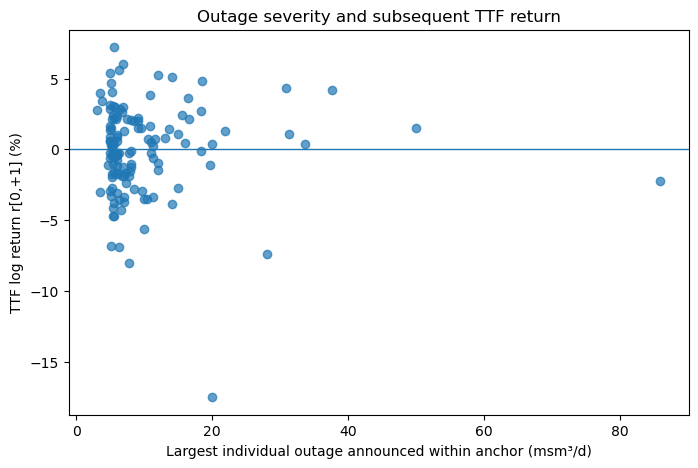

In [22]:
# Signed post-anchor return versus outage severity

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    severity_analysis["max_outage_size_msm3d"],
    100 * severity_analysis["return_0_p1"],
    alpha=0.7
)

ax.axhline(0, linewidth=1)

ax.set_xlabel(
    "Largest individual outage announced within anchor (msm³/d)"
)
ax.set_ylabel(
    "TTF log return r[0,+1] (%)"
)
ax.set_title(
    "Outage severity and subsequent TTF return"
)

plt.show()

In [23]:
# Descriptive dependence measures

severity_relationships = pd.DataFrame({
    "relationship": [
        "Outage size vs signed return",
        "Outage size vs absolute return"
    ],
    "pearson": [
        severity_analysis[
            ["max_outage_size_msm3d", "return_0_p1"]
        ].corr(method="pearson").iloc[0, 1],

        severity_analysis[
            ["max_outage_size_msm3d", "abs_return_0_p1"]
        ].corr(method="pearson").iloc[0, 1]
    ],
    "spearman": [
        severity_analysis[
            ["max_outage_size_msm3d", "return_0_p1"]
        ].corr(method="spearman").iloc[0, 1],

        severity_analysis[
            ["max_outage_size_msm3d", "abs_return_0_p1"]
        ].corr(method="spearman").iloc[0, 1]
    ]
})

display(
    severity_relationships.round(3)
)

,relationship,pearson,spearman
0,Outage size vs signed return,-0.014,-0.006
1,Outage size vs absolute return,0.068,0.015


### Outage severity and TTF response

The largest individual outage communicated within each market anchor shows little unconditional relationship with the subsequent TTF price movement.

For the post-anchor \([0,+1]\) return, the Pearson correlation between outage magnitude and signed return is -0.014, while the Spearman rank correlation is -0.006. The corresponding correlations with absolute return magnitude are 0.068 and 0.015.

The similarity of the Pearson and Spearman results indicates that the absence of a strong relationship is not simply an artefact of the highly right-skewed outage-size distribution.

Large announced capacity reductions are followed by both positive and negative TTF movements, while some of the largest market moves occur around considerably smaller outages. Headline outage magnitude alone therefore provides little descriptive information about either the direction or magnitude of the subsequent TTF return in this sample.

This does not imply that physical supply losses are irrelevant to TTF pricing. `max_outage_size_msm3d` measures the largest individual capacity reduction communicated within an anchor, rather than the unexpected change in aggregate Norwegian supply available to the market. Market response may depend on whether the information was anticipated, when it was published, which infrastructure was affected, the expected duration of the constraint and prevailing gas-market conditions.

In [24]:
# Identify the largest individual outage announcement
# within each TTF anchor and retain its own characteristics.

largest_announcement = (
    announcements
    .sort_values(
        [
            "date_0",
            "outage_size_msm3d",
            "publication_time"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .groupby("date_0", as_index=False)
    .first()
)

largest_announcement = (
    largest_announcement[
        [
            "date_0",
            "message_id",
            "asset",
            "event_type",
            "reason",
            "outage_size_msm3d",
            "lead_hours",
            "duration_hours",
            "publication_timing_group"
        ]
    ]
    .rename(
        columns={
            "message_id": "largest_message_id",
            "asset": "largest_asset",
            "event_type": "largest_event_type",
            "reason": "largest_reason",
            "outage_size_msm3d":
                "largest_outage_size_msm3d",
            "lead_hours":
                "largest_outage_lead_hours",
            "duration_hours":
                "largest_outage_duration_hours",
            "publication_timing_group":
                "largest_outage_timing_group"
        }
    )
)

severity_timing = (
    event_heterogeneity
    .merge(
        largest_announcement,
        on="date_0",
        how="left",
        validate="one_to_one"
    )
)

print("Rows:", len(severity_timing))

print("\nTiming of largest outage announcement:")
display(
    severity_timing[
        "largest_outage_timing_group"
    ]
    .value_counts()
    .rename_axis("timing_group")
    .reset_index(name="n_anchors")
)

print("\nLead-time distribution of largest outage:")
display(
    severity_timing[
        "largest_outage_lead_hours"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
    .round(2)
)

Rows: 130

Timing of largest outage announcement:


,timing_group,n_anchors
0,published_after_start,90
1,published_before_or_at_start,40



Lead-time distribution of largest outage:


count    130.00
mean      -0.14
std       10.70
min      -33.53
10%      -11.15
25%       -4.51
50%       -0.06
75%        3.94
90%       11.80
max       66.23
Name: largest_outage_lead_hours, dtype: float64

In [25]:
# TTF response by publication timing of the largest outage

timing_summary = (
    severity_timing
    .groupby("largest_outage_timing_group")
    ["return_0_p1"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        std="std"
    )
)

timing_summary[
    ["mean", "median", "std"]
] *= 100

display(
    timing_summary.round(3)
)

,n,mean,median,std
largest_outage_timing_group,,,,
published_after_start,90,0.078,-0.194,2.953
published_before_or_at_start,40,-0.414,0.440,3.905


### Publication timing

The largest outage announcement within each market anchor was published after operational start for 90 of the 130 anchors and before or at operational start for the remaining 40.

The post-anchor return distribution does not reveal a simple directional relationship with publication timing. Mean \([0,+1]\) returns are +0.08% for outages published after operational start and -0.41% for those published before or at start. However, the corresponding medians are -0.19% and +0.44%, respectively.

The disagreement between the group means and medians, together with the higher return dispersion in the before-or-at-start group, indicates that the mean difference is sensitive to the shape and tails of the return distribution. The descriptive comparison therefore does not provide evidence of a straightforward directional timing effect.

Publication relative to operational start should also not be interpreted as a direct measure of market surprise. It identifies when Gassco published the outage relative to the stated physical start of the constraint, but does not establish what market participants expected beforehand.

In [26]:
# Inspect return tails within each timing group

timing_tail_summary = (
    severity_timing
    .groupby("largest_outage_timing_group")
    ["return_0_p1"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        p10=lambda x: x.quantile(0.10),
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        maximum="max"
    )
)

timing_tail_summary[
    [
        "mean", "median", "std",
        "minimum", "p10", "p25",
        "p75", "p90", "maximum"
    ]
] *= 100

display(timing_tail_summary.round(3))

,n,mean,median,std,minimum,p10,p25,p75,p90,maximum
largest_outage_timing_group,,,,,,,,,,
published_after_start,90,0.078,-0.194,2.953,-7.997,-3.519,-1.750,2.128,4.010,7.210
published_before_or_at_start,40,-0.414,0.440,3.905,-17.493,-4.698,-1.554,1.631,2.835,6.021


In [27]:
# Largest positive and negative observations by timing group

tail_events = (
    severity_timing[
        [
            "date_0",
            "largest_asset",
            "largest_outage_size_msm3d",
            "largest_outage_lead_hours",
            "largest_outage_timing_group",
            "return_0_p1"
        ]
    ]
    .copy()
)

tail_events["return_pct"] = (
    100 * tail_events["return_0_p1"]
)

for group in tail_events[
    "largest_outage_timing_group"
].unique():

    print(f"\n{group}")

    group_data = tail_events.loc[
        tail_events["largest_outage_timing_group"] == group
    ]

    print("\nMost negative:")
    display(
        group_data
        .nsmallest(5, "return_0_p1")
        .drop(columns="return_0_p1")
    )

    print("Most positive:")
    display(
        group_data
        .nlargest(5, "return_0_p1")
        .drop(columns="return_0_p1")
    )


published_after_start

Most negative:


,date_0,largest_asset,largest_outage_size_msm3d,largest_outage_lead_hours,largest_outage_timing_group,return_pct
37,2025-02-12,Troll,7.7,-6.674444,published_after_start,-7.997234
105,2026-05-22,Visund,6.3,-0.013333,published_after_start,-6.915721
90,2026-04-13,Norne,5.1,-5.486944,published_after_start,-6.792693
109,2026-06-14,Oseberg,6.6,-2.825556,published_after_start,-4.244394
92,2026-04-19,Åsgard,5.4,-15.301389,published_after_start,-4.139763


Most positive:


,date_0,largest_asset,largest_outage_size_msm3d,largest_outage_lead_hours,largest_outage_timing_group,return_pct
96,2026-04-28,Aasta Hansteen,5.6,-0.010000,published_after_start,7.209551
87,2026-03-06,Oseberg,6.2,-1.881667,published_after_start,5.587863
49,2025-05-05,Dvalin,5.0,-2.597778,published_after_start,5.359402
6,2024-09-24,Sleipner,12.0,-1.910556,published_after_start,5.242360
118,2026-07-17,Kristin,14.0,-0.173889,published_after_start,5.103191



published_before_or_at_start

Most negative:


,date_0,largest_asset,largest_outage_size_msm3d,largest_outage_lead_hours,largest_outage_timing_group,return_pct
88,2026-03-09,Nyhamna,20.0,0.008056,published_before_or_at_start,-17.493390
42,2025-04-03,Kollsnes,28.0,13.360556,published_before_or_at_start,-7.415703
2,2024-09-09,Gullfaks,10.0,2.417500,published_before_or_at_start,-5.650474
104,2026-05-19,Åsgard,5.4,16.819722,published_before_or_at_start,-4.724261
16,2024-10-29,Skarv,5.5,10.655833,published_before_or_at_start,-4.694554


Most positive:


,date_0,largest_asset,largest_outage_size_msm3d,largest_outage_lead_hours,largest_outage_timing_group,return_pct
98,2026-05-03,Åsgard,6.8,7.653056,published_before_or_at_start,6.020668
4,2024-09-19,Heidrun,5.2,10.049167,published_before_or_at_start,4.031526
129,2026-08-31,Dvalin,3.8,0.101667,published_before_or_at_start,3.392638
48,2025-05-01,Gullfaks,6.4,19.215833,published_before_or_at_start,2.848706
17,2024-11-01,Johan Sverdrup,4.9,6.470278,published_before_or_at_start,2.833749


### Publication timing and return tails

The difference in mean returns between publication-timing groups is strongly influenced by the lower tail of the before-or-at-start sample.

Among the 40 anchors in this group, the 9 March 2026 observation records a post-anchor return of approximately -17.49%. The next-largest negative observation is approximately -7.42%. This helps explain why the group's mean return (-0.41%) is negative while its median return (+0.44%) is positive.

The after-start group displays a less extreme range, from approximately -8.00% to +7.21%, and similarly contains substantial movements in both directions.

The timing comparison therefore provides no clear descriptive evidence of a common directional response based solely on whether the largest outage was published before or after operational start. In particular, the negative mean of the before-or-at-start group should not be interpreted independently of its extreme lower-tail observation.

Publication timing remains economically relevant, but the results reinforce the distinction between operational timing and market surprise. Knowing that an outage was published before physical start does not establish whether the information itself was unexpected.

## Formal statistical analysis

Formal inference is restricted to a small set of questions motivated by the preceding descriptive analysis.

The primary response variable is the post-anchor \([0,+1]\) TTF log return. This window is preferred because it measures price movement after the first observed TTF anchor associated with the announcement, whereas the \([-1,0]\) interval may partly precede publication for same-date announcements.

Three questions are examined:

1. whether the typical post-anchor return differs from zero;
2. whether outage magnitude has a monotonic association with the post-anchor return; and
3. whether the return distribution differs according to whether the largest outage announcement was published before or after operational start.

The tests are interpreted cautiously. Event observations are not assumed to represent isolated causal shocks, and overlapping market windows can induce dependence between observations. Formal inference is based on the 82 non-overlapping anchors to reduce dependence created by overlapping event windows. The tests are interpreted cautiously. Event observations are not assumed to represent isolated causal shocks, and overlapping market windows can induce dependence between observations. Formal inference is based on the 82 non-overlapping anchors to reduce dependence created by overlapping event windows. The 130 unique-anchor sample is retained for descriptive comparison.

Statistical significance is not interpreted as evidence that an outage announcement caused the corresponding TTF movement. The tests assess features of the observed event-return distribution conditional on the event construction used in this study.

### 1. Is the typical post-anchor TTF return different from zero?

The first inferential test examines whether the post-anchor \([0,+1]\) return distribution is centred away from zero.

The null hypothesis is that there is no systematic location shift in the post-anchor return distribution. The alternative is that the distribution is systematically shifted away from zero.

Because the return distribution contains substantial tails and the mean and median do not always provide the same impression, inference is not based solely on a conventional one-sample t-test. The median is estimated with a bootstrap confidence interval, while a Wilcoxon signed-rank test provides a complementary non-parametric location test.

Results are shown for the 130 unique market anchors for descriptive comparison, while formal inference is based on the 82 non-overlapping anchors to reduce mechanical dependence created by overlapping event windows.

In [28]:
from scipy import stats

# Full unique-anchor sample retained for descriptive comparison

event_returns = (
    anchors["return_0_p1"]
    .dropna()
    .to_numpy()
)

n_boot = 10_000

print("Unique-anchor descriptive sample")
print("--------------------------------")
print(f"n: {len(event_returns)}")
print(
    "Observed median:",
    f"{100 * np.median(event_returns):.3f}%"
)

Unique-anchor descriptive sample
--------------------------------
n: 130
Observed median: 0.279%


### Typical post-anchor return

The 130 unique event anchors have a median post-anchor \([0,+1]\) return of +0.279%. This full sample is retained as a descriptive reference because some event windows overlap in trading time.

Formal inference is based on the 82 non-overlapping anchors. Their median post-anchor return is +0.057%, with a 95% bootstrap confidence interval of -0.526% to +0.925%. The Wilcoxon signed-rank test also provides no evidence of a systematic location shift away from zero (W = 1615, p = 0.689).

The inferential result therefore does not provide evidence of a common directional post-anchor TTF response away from zero.

This should not be interpreted as evidence that Norwegian outage information has no effect on TTF prices. Failure to reject a zero location shift is not equivalent to demonstrating that the true effect is zero. Heterogeneous responses, market expectations, contemporaneous information and differences between individual outages may obscure an unconditional response.

In [29]:
nonoverlap_returns = (
    nonoverlap["return_0_p1"]
    .dropna()
    .to_numpy()
)

rng = np.random.default_rng(22592218)

bootstrap_medians_nonoverlap = np.empty(
    n_boot
)

for i in range(n_boot):
    bootstrap_sample = rng.choice(
        nonoverlap_returns,
        size=len(nonoverlap_returns),
        replace=True
    )

    bootstrap_medians_nonoverlap[i] = (
        np.median(bootstrap_sample)
    )

nonoverlap_median = np.median(
    nonoverlap_returns
)

nonoverlap_ci_lower, nonoverlap_ci_upper = (
    np.percentile(
        bootstrap_medians_nonoverlap,
        [2.5, 97.5]
    )
)

nonoverlap_wilcoxon = stats.wilcoxon(
    nonoverlap_returns,
    alternative="two-sided",
    zero_method="wilcox"
)

print("Non-overlapping sample")
print("----------------------")
print(f"n: {len(nonoverlap_returns)}")

print(
    f"Observed median: "
    f"{100 * nonoverlap_median:.3f}%"
)

print(
    f"95% bootstrap CI: "
    f"[{100 * nonoverlap_ci_lower:.3f}%, "
    f"{100 * nonoverlap_ci_upper:.3f}%]"
)

print(
    f"Wilcoxon statistic: "
    f"{nonoverlap_wilcoxon.statistic:.3f}"
)

print(
    f"Wilcoxon p-value: "
    f"{nonoverlap_wilcoxon.pvalue:.4f}"
)

Non-overlapping sample
----------------------
n: 82
Observed median: 0.057%
95% bootstrap CI: [-0.526%, 0.925%]
Wilcoxon statistic: 1615.000
Wilcoxon p-value: 0.6892


### 2. Outage magnitude and subsequent TTF return

The second inferential question examines whether larger outage announcements are systematically associated with higher or lower post-anchor TTF returns.

Spearman's rank correlation is used as the primary measure because outage magnitude is strongly right-skewed and the test does not require a linear relationship between outage size and return.

The null hypothesis is that there is no monotonic association between the largest individual outage communicated within an anchor and the subsequent \([0,+1]\) return.

The 130 unique-anchor sample is retained for descriptive comparison, while formal inference is based on the 82 non-overlapping anchors to reduce dependence created by overlapping event windows.

In [30]:
# Full unique-anchor sample: descriptive correlation only

spearman_full_rho = (
    severity_timing[
        ["largest_outage_size_msm3d", "return_0_p1"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print("Unique-anchor sample")
print("--------------------")
print(f"n: {len(severity_timing)}")
print(f"Spearman rho: {spearman_full_rho:.4f}")


# Non-overlapping sample

severity_nonoverlap = (
    nonoverlap[["date_0", "return_0_p1"]]
    .merge(
        severity_timing[
            [
                "date_0",
                "largest_outage_size_msm3d"
            ]
        ],
        on="date_0",
        how="left",
        validate="one_to_one"
    )
)

assert (
    severity_nonoverlap[
        "largest_outage_size_msm3d"
    ].notna().all()
)

spearman_nonoverlap = stats.spearmanr(
    severity_nonoverlap[
        "largest_outage_size_msm3d"
    ],
    severity_nonoverlap["return_0_p1"]
)

print("\nNon-overlapping sample")
print("----------------------")
print(f"n: {len(severity_nonoverlap)}")
print(
    f"Spearman rho: "
    f"{spearman_nonoverlap.statistic:.4f}"
)
print(
    f"p-value: "
    f"{spearman_nonoverlap.pvalue:.4f}"
)

Unique-anchor sample
--------------------
n: 130
Spearman rho: -0.0056

Non-overlapping sample
----------------------
n: 82
Spearman rho: 0.0500
p-value: 0.6556


### Outage magnitude and subsequent TTF return

There is no evidence of a monotonic relationship between the largest individual outage communicated within an event anchor and the subsequent TTF return.

Across the 130 unique event anchors, Spearman's rank correlation between outage magnitude and the post-anchor \([0,+1]\) return is -0.006. The estimated association is therefore close to zero in the full descriptive sample.

Formal inference is based on the 82 non-overlapping anchors. The Spearman correlation is +0.050 with a p-value of 0.656, providing no evidence of a monotonic association between outage magnitude and the subsequent TTF return.
These results reinforce the earlier descriptive finding that headline outage magnitude alone provides little information about the direction of the subsequent TTF movement. They do not imply that Norwegian supply availability is irrelevant to TTF pricing. The measured outage size is not equivalent to an unexpected supply shock, and the market response may depend on prior expectations, publication timing, affected infrastructure, outage duration and prevailing market conditions.

### 3. Publication timing and subsequent TTF return

The final comparison examines whether post-anchor returns differ according to the publication timing of the largest outage announcement.

Anchors are divided according to whether the largest individual outage was published after operational start or before or at operational start.

Because the return distributions contain substantial tails and the group means and medians provide different impressions, the primary comparison uses a two-sided Mann–Whitney U test rather than an equal-variance two-sample t-test.

The null hypothesis is that the two groups have the same return distribution. The test is interpreted as a rank-based distributional comparison rather than, without additional assumptions, as a test solely of equality of medians.

In [31]:
# Separate the two timing groups

after_start = (
    severity_timing.loc[
        severity_timing[
            "largest_outage_timing_group"
        ] == "published_after_start",
        "return_0_p1"
    ]
    .dropna()
    .to_numpy()
)

before_start = (
    severity_timing.loc[
        severity_timing[
            "largest_outage_timing_group"
        ] == "published_before_or_at_start",
        "return_0_p1"
    ]
    .dropna()
    .to_numpy()
)

print("Unique-anchor sample")
print("--------------------")
print(f"After-start n: {len(after_start)}")
print(f"Before/at-start n: {len(before_start)}")

print(
    f"After-start median: "
    f"{100 * np.median(after_start):.3f}%"
)

print(
    f"Before/at-start median: "
    f"{100 * np.median(before_start):.3f}%"
)


Unique-anchor sample
--------------------
After-start n: 90
Before/at-start n: 40
After-start median: -0.194%
Before/at-start median: 0.440%


In [32]:
timing_nonoverlap = (
    nonoverlap[["date_0", "return_0_p1"]]
    .merge(
        severity_timing[
            [
                "date_0",
                "largest_outage_timing_group"
            ]
        ],
        on="date_0",
        how="left",
        validate="one_to_one"
    )
)

assert (
    timing_nonoverlap[
        "largest_outage_timing_group"
    ].notna().all()
)

after_start_nonoverlap = (
    timing_nonoverlap.loc[
        timing_nonoverlap[
            "largest_outage_timing_group"
        ] == "published_after_start",
        "return_0_p1"
    ]
    .to_numpy()
)

before_start_nonoverlap = (
    timing_nonoverlap.loc[
        timing_nonoverlap[
            "largest_outage_timing_group"
        ] == "published_before_or_at_start",
        "return_0_p1"
    ]
    .to_numpy()
)

mannwhitney_nonoverlap = stats.mannwhitneyu(
    after_start_nonoverlap,
    before_start_nonoverlap,
    alternative="two-sided"
)

print("Non-overlapping sample")
print("----------------------")

print(
    f"After-start n: "
    f"{len(after_start_nonoverlap)}"
)

print(
    f"Before/at-start n: "
    f"{len(before_start_nonoverlap)}"
)

print(
    f"After-start median: "
    f"{100 * np.median(after_start_nonoverlap):.3f}%"
)

print(
    f"Before/at-start median: "
    f"{100 * np.median(before_start_nonoverlap):.3f}%"
)

print(
    f"Mann-Whitney U: "
    f"{mannwhitney_nonoverlap.statistic:.3f}"
)

print(
    f"p-value: "
    f"{mannwhitney_nonoverlap.pvalue:.4f}"
)

Non-overlapping sample
----------------------
After-start n: 59
Before/at-start n: 23
After-start median: -0.246%
Before/at-start median: 0.753%
Mann-Whitney U: 612.000
p-value: 0.4957


### Publication-timing inference

The rank-based comparison provides no evidence that post-anchor TTF returns systematically differ according to whether the largest outage was published before or after operational start.

Across the 130 unique anchors, the median post-anchor return is -0.194% for outages published after operational start and +0.440% for outages published before or at operational start. These full-sample medians are retained as descriptive context.

Formal inference is based on the 82 non-overlapping anchors. Median returns are -0.246% and +0.753%, respectively, while the Mann–Whitney test provides no evidence of systematic distributional separation between the groups (U = 612, p = 0.496).

The results therefore do not support a simple relationship between publication relative to operational start and subsequent TTF return. Publication timing should not be interpreted as equivalent to market surprise, since the analysis does not observe prior market expectations.

In [33]:
# Consolidate formal inference from the non-overlapping sample

inference_results = pd.DataFrame([
    {
        "question": "Return location vs zero",
        "sample": "Non-overlapping",
        "n": len(nonoverlap_returns),
        "estimate": (
            f"Median = {100 * nonoverlap_median:.3f}%"
        ),
        "statistic": (
            f"W = {nonoverlap_wilcoxon.statistic:.0f}"
        ),
        "p_value": nonoverlap_wilcoxon.pvalue,
    },
    {
        "question": "Outage size vs return",
        "sample": "Non-overlapping",
        "n": len(severity_nonoverlap),
        "estimate": (
            f"Spearman rho = "
            f"{spearman_nonoverlap.statistic:.3f}"
        ),
        "statistic": "",
        "p_value": spearman_nonoverlap.pvalue,
    },
    {
        "question": "Publication timing",
        "sample": "Non-overlapping",
        "n": len(timing_nonoverlap),
        "estimate": (
            f"Medians = "
            f"{100 * np.median(after_start_nonoverlap):.3f}% / "
            f"{100 * np.median(before_start_nonoverlap):.3f}%"
        ),
        "statistic": (
            f"U = {mannwhitney_nonoverlap.statistic:.0f}"
        ),
        "p_value": mannwhitney_nonoverlap.pvalue,
    },
])

display(
    inference_results.round(
        {"p_value": 4}
    )
)

,question,sample,n,estimate,statistic,p_value
0,Return location vs zero,Non-overlapping,82,Median = 0.057%,W = 1615,0.6892
1,Outage size vs return,Non-overlapping,82,Spearman rho = 0.050,,0.6556
2,Publication timing,Non-overlapping,82,Medians = -0.246% / 0.753%,U = 612,0.4957


### Inferential summary

Formal inference is based on the 82 non-overlapping event anchors.

Across this sample, the post-anchor return distribution does not show a statistically detectable common location shift away from zero. The largest individual outage magnitude also shows no evidence of a monotonic association with the subsequent return, while the publication-timing groups do not show systematic rank separation.

These results should not be interpreted as demonstrating that Norwegian gas outages have no effect on TTF prices. Rather, the analysis finds no common unconditional response using the event definitions and daily price data employed here. Individual market reactions may depend on the unexpected component of the supply loss, affected infrastructure, duration, prevailing market conditions and contemporaneous information.

### Case study: 9 March 2026 and contemporaneous market information

The extreme event returns illustrate an important identification problem in the event study.

On 9 March 2026, the event dataset associates the TTF anchor with a 20 mcm/d outage at Nyhamna. The subsequent [0,+1] return is -17.49%, making it the most negative observation in the primary return window.

Interpreting this movement as the effect of the Norwegian outage would, however, be misleading. March 2026 was an exceptionally volatile period for global gas markets. The disruption of LNG flows through the Strait of Hormuz and the loss of Qatari LNG production generated a major global supply shock. The IEA subsequently reported that TTF month-ahead volatility reached approximately 160% during March.

On 9 March itself, European gas prices initially surged as the Middle East conflict intensified. S&P Global reported that the April TTF contract opened approximately 29% above the previous settlement before subsequently retreating from its intraday highs. Market commentary for the following session attributed a sharp decline in TTF partly to easing concerns over a prolonged Middle East conflict.

The Nyhamna announcement therefore occurred within an unusually large geopolitical and LNG repricing episode. The observed event-window return cannot be interpreted as the isolated price effect of the Norwegian outage.

This case demonstrates why event-window returns in this study measure market movements around outage announcements rather than causal outage effects. Contemporaneous information can dominate the daily TTF return even when a Norwegian supply disruption is economically relevant.

In [34]:
# Select the 10 largest absolute post-anchor TTF movements
# using a rule defined before researching the individual dates.

case_studies = (
    severity_timing
    .assign(
        abs_return_0_p1=lambda x: x["return_0_p1"].abs()
    )
    .sort_values(
        "abs_return_0_p1",
        ascending=False
    )
    [
        [
            "date_0",
            "largest_asset",
            "largest_event_type",
            "largest_reason",
            "largest_outage_size_msm3d",
            "largest_outage_lead_hours",
            "largest_outage_timing_group",
            "n_announcements",
            "n_assets",
            "return_0_p1",
            "abs_return_0_p1"
        ]
    ]
    .head(10)
    .copy()
)

# Scale log returns by 100 for readability
case_studies["return_0_p1_pct"] = (
    100 * case_studies["return_0_p1"]
)

case_studies["abs_return_0_p1_pct"] = (
    100 * case_studies["abs_return_0_p1"]
)

display(
    case_studies[
        [
            "date_0",
            "largest_asset",
            "largest_event_type",
            "largest_reason",
            "largest_outage_size_msm3d",
            "largest_outage_lead_hours",
            "largest_outage_timing_group",
            "n_announcements",
            "n_assets",
            "return_0_p1_pct",
            "abs_return_0_p1_pct"
        ]
    ]
)

,date_0,largest_asset,largest_event_type,largest_reason,largest_outage_size_msm3d,largest_outage_lead_hours,largest_outage_timing_group,n_announcements,n_assets,return_0_p1_pct,abs_return_0_p1_pct
88,2026-03-09,Nyhamna,Gas treatment plant unavailability,Compressor failure,20.0,0.008056,published_before_or_at_start,1,1,-17.493390,17.493390
37,2025-02-12,Troll,Gas production field unavailability,Process problems,7.7,-6.674444,published_after_start,3,2,-7.997234,7.997234
42,2025-04-03,Kollsnes,Gas treatment plant unavailability,Failure – external power supply,28.0,13.360556,published_before_or_at_start,1,1,-7.415703,7.415703
96,2026-04-28,Aasta Hansteen,Gas production field unavailability,Process problems,5.6,-0.010000,published_after_start,1,1,7.209551,7.209551
105,2026-05-22,Visund,Gas production field unavailability,Process problems,6.3,-0.013333,published_after_start,1,1,-6.915721,6.915721
90,2026-04-13,Norne,Gas production field unavailability,Process problems,5.1,-5.486944,published_after_start,1,1,-6.792693,6.792693
98,2026-05-03,Åsgard,Gas production field unavailability,Process problems,6.8,7.653056,published_before_or_at_start,1,1,6.020668,6.020668
2,2024-09-09,Gullfaks,Other unavailability,Process problems,10.0,2.417500,published_before_or_at_start,2,2,-5.650474,5.650474
87,2026-03-06,Oseberg,Gas production field unavailability,Corrective maintenance,6.2,-1.881667,published_after_start,1,1,5.587863,5.587863
49,2025-05-05,Dvalin,Gas production field unavailability,Corrective maintenance,5.0,-2.597778,published_after_start,1,1,5.359402,5.359402


## Extreme-return event-window audit

The ten largest absolute post-anchor [0,+1] returns are examined as a diagnostic of event-window attribution.

The observations were selected mechanically according to absolute return magnitude before contemporaneous market information was reviewed. The exercise is therefore not intended to estimate the frequency of competing shocks across the full event sample or to explain the preceding statistical results.

Instead, the audit asks whether the most extreme observed returns coincide with other documented information that was plausibly relevant to European gas pricing. Evidence is collected from market reporting and primary or institutional sources covering LNG supply, European gas fundamentals, geopolitical developments, Norwegian supply and other material energy-market information.

The presence of contemporaneous market information does not demonstrate that the focal Norwegian outage had no price effect. It instead limits the extent to which the observed daily TTF return can be attributed to that outage in isolation.

Because publication timestamps, market-news timestamps and the daily price series cannot always be placed on a common verified intraday clock, sequencing is treated cautiously.